This includes analysis of the outputs from the San Luis Storage, input and output for the Argon national lab study by Quentin.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Initialize an empty list to store all delta change values
all_changes = []

In [3]:
for year in range(1996, 2022):
    print(year)
    
    for all_years in range(1996,2024):
        
        # Set up the results validation path
        results_folder = f"../Annual_Ensembles/results/{year}/{all_years}"
        
        #Read the input file
        input_data = pd.read_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index_col=0)
        
        #Lag the Banks and Tracy Reservoirs
        input_data['Lagged_Storage'] = input_data['Storage'].shift(-1)
        input_data['Lagged_Release'] = input_data['Lagged_Storage'] - input_data['Storage']
        
        #Compute the difference
        input_data['Delta_Change'] = input_data['Inflow'] - input_data['Lagged_Release'] - input_data['Outflow']
        
        #Remove 1st and last values
        #input_data = input_data.iloc[1:-1]
        
        # Add all delta change values to the master list
        all_changes.extend(input_data['Delta_Change'].tolist())


1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021


In [4]:
input_data

,Inflow,Storage,Releases,Outflow,Lagged_Storage,Lagged_Release,Delta_Change
2020-10-01,11.850953,914.800000,0.000000,12.009528,914.641425,-0.158575,-1.492140e-13
2020-10-02,8.822247,914.641425,0.158575,10.243307,913.220364,-1.421060,1.261213e-13
2020-10-03,9.141836,913.220364,1.421060,10.255522,912.106678,-1.113686,-1.296740e-13
2020-10-04,9.133728,912.106678,1.113686,9.700007,911.540399,-0.566279,5.684342e-14
2020-10-05,9.784567,911.540399,0.566279,11.724155,909.600810,-1.939588,-3.019807e-14
...,...,...,...,...,...,...,...
2021-09-26,17.541308,1265.035656,-0.158347,19.137913,1263.438819,-1.596837,2.320532e-04
2021-09-27,20.248876,1263.438819,1.596837,17.653991,1266.033047,2.594228,6.570394e-04
2021-09-28,18.835451,1266.033047,-2.594228,20.221569,1264.646962,-1.386085,-3.355123e-05
2021-09-29,21.431399,1264.646962,1.386085,20.958113,1265.120452,0.473490,-2.041134e-04


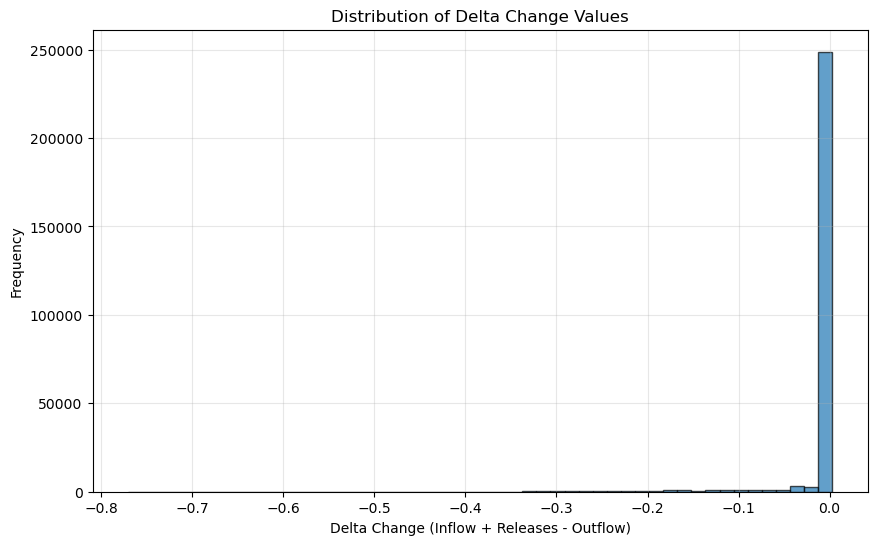

In [5]:
# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(all_changes, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Delta Change (Inflow + Releases - Outflow)')
plt.ylabel('Frequency')
plt.title('Distribution of Delta Change Values')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
#Remove the storage

for year in range(1996, 2024):
    print(year)
    
    for all_years in range(1996,2024):
        
        # Set up the results validation path
        results_folder = f"../Annual_Ensembles/results/{year}/{all_years}"
        
        #Read the input file
        input_data = pd.read_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index_col=0)
        
        #Lag the Banks and Tracy Reservoirs
        input_data['Lagged_Storage'] = input_data['Storage'].shift(-1)
        input_data['Releases'] = input_data['Lagged_Storage'] - input_data['Storage']
        
        #Compute the difference
        input_data['Delta_Change'] = input_data['Inflow'] - input_data['Releases'] - input_data['Outflow']
        input_data.drop('Lagged_Storage', axis=1, inplace=True)
        input_data.drop('Delta_Change', axis=1, inplace=True)
        
        print(input_data)

        input_data.to_csv(f"{results_folder}/Daily_San_Luis_Outputs.csv", index=True)

1996
               Inflow     Storage  Releases    Outflow
1995-10-01  21.778512  914.800000  8.977760  12.800753
1995-10-02   9.720814  923.777760 -3.234266  12.955080
1995-10-03  10.418057  920.543494 -2.485620  12.903677
1995-10-04  11.996571  918.057874  0.167625  11.828947
1995-10-05  12.619695  918.225498 -1.926487  14.546181
...               ...         ...       ...        ...
1996-09-26  21.778512  786.509109  4.454371  17.326407
1996-09-27  21.778512  790.963480  3.100361  18.680452
1996-09-28  21.778512  794.063841  2.916070  18.864714
1996-09-29  21.778512  796.979911  1.202235  20.578520
1996-09-30  21.778512  798.182147       NaN  15.062938

[366 rows x 4 columns]
               Inflow     Storage  Releases    Outflow
1995-10-01  14.397157  914.800000  1.607396  12.789761
1995-10-02   9.575241  916.407396 -3.400235  12.975476
1995-10-03  12.723988  913.007161 -0.221527  12.945515
1995-10-04  11.849678  912.785634  0.066396  11.783282
1995-10-05  11.690841  912.852030 -3

               Inflow      Storage  Releases    Outflow
1995-10-01  14.464939   914.800000  1.675667  12.789272
1995-10-02   9.930532   916.475667 -3.117332  13.047863
1995-10-03  11.440752   913.358335 -1.594267  13.035019
1995-10-04  10.980690   911.764068 -0.956860  11.937550
1995-10-05  11.774197   910.807208 -2.925550  14.699747
...               ...          ...       ...        ...
1996-09-26  21.778512  1218.660507  3.762446  18.242796
1996-09-27  21.778512  1222.422953  1.995133  19.976595
1996-09-28  21.778512  1224.418086  2.069115  19.879933
1996-09-29  21.778512  1226.487201 -0.694899  22.627003
1996-09-30  21.778512  1225.792302       NaN  16.679886

[366 rows x 4 columns]
               Inflow     Storage   Releases    Outflow
1995-10-01  14.398314  914.800000   1.617559  12.780755
1995-10-02  10.115702  916.417559  -2.912690  13.028393
1995-10-03  11.437717  913.504869  -1.578378  13.016095
1995-10-04  10.115702  911.926491  -1.814332  11.930035
1995-10-05  17.803534  9

               Inflow      Storage  Releases    Outflow
1996-10-01  12.274927   914.800000 -0.484810  12.759737
1996-10-02   6.906457   914.315190 -6.314577  13.221034
1996-10-03  16.872013   908.000613  3.391324  13.480689
1996-10-04  16.760067   911.391937  4.428284  12.331782
1996-10-05  10.115702   915.820221 -4.837831  14.953533
...               ...          ...       ...        ...
1997-09-26  21.778512  1015.982836  9.815830  12.431295
1997-09-27  21.778512  1025.798666  9.973909  12.124363
1997-09-28  21.778512  1035.772575  9.946444  12.150767
1997-09-29  21.778512  1045.719019  8.740986  13.067363
1997-09-30  21.778512  1054.460005       NaN  15.596556

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
1996-10-01  11.991345   914.800000 -0.688049  12.679394
1996-10-02   8.416481   914.111951 -4.620064  13.036545
1996-10-03   8.838219   909.491887 -3.938010  12.776229
1996-10-04   8.917450   905.553877 -3.090652  12.008102
1996-10-05  10.115702   

               Inflow      Storage   Releases    Outflow
1996-10-01  12.040525   914.800000  -0.646931  12.687457
1996-10-02   4.583756   914.153069  -8.260898  12.844654
1996-10-03   4.761545   905.892171  -7.597113  12.358658
1996-10-04   4.356079   898.295058  -7.446861  11.802939
1996-10-05   4.707857   890.848197  -9.670195  14.378052
...               ...          ...        ...        ...
1997-09-26  18.030078  1088.205221  10.198547   7.831532
1997-09-27  17.498237  1098.403768   5.020216  12.490199
1997-09-28  17.246760  1103.423983   5.367797  11.888295
1997-09-29  16.903646  1108.791780   4.528706  12.381420
1997-09-30  21.778512  1113.320486        NaN  15.615964

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
1996-10-01  12.047006   914.800000 -0.649684  12.696689
1996-10-02   9.053906   914.150316 -4.194026  13.247932
1996-10-03  10.115702   909.956290 -3.215832  13.331534
1996-10-04  10.115702   906.740459 -2.337517  12.453219
1996-10-05  

               Inflow      Storage   Releases    Outflow
1997-10-01  12.726086   914.800000   0.472000  12.254085
1997-10-02   9.563886   915.272000  -2.375024  11.938909
1997-10-03  10.115702   912.896977  -0.935090  11.050793
1997-10-04  10.115702   911.961886  -1.223758  11.339461
1997-10-05  10.115702   910.738128  -4.004193  14.119895
...               ...          ...        ...        ...
1998-09-26  21.778512  1049.650268  10.242643  11.679683
1998-09-27  21.616130  1059.892911   9.972058  11.779652
1998-09-28  21.778512  1069.864970   9.477665  12.498816
1998-09-29  21.616130  1079.342635   8.324410  13.298558
1998-09-30  21.778512  1087.667044        NaN  14.051421

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
1997-10-01  12.728022   914.800000  0.473909  12.254113
1997-10-02  10.754580   915.273909 -1.644662  12.399243
1997-10-03  10.115702   913.629247 -1.427183  11.542885
1997-10-04  10.198806   912.202064 -1.554590  11.753395
1997-10-05  

...

               Inflow      Storage   Releases    Outflow
2020-10-01  11.878123   914.800000  -0.137566  12.015690
2020-10-02  10.117707   914.662434  -0.689477  10.807184
2020-10-03  12.320158   913.972956   1.157341  11.162817
2020-10-04  10.115702   915.130297  -0.486600  10.602302
2020-10-05  10.115702   914.643697  -3.484667  13.600370
...               ...          ...        ...        ...
2021-09-26  21.778512  1000.754631  10.550862  11.227651
2021-09-27  21.778512  1011.305493   7.439180  14.340782
2021-09-28  21.778512  1018.744673   7.416231  14.363163
2021-09-29  21.778512  1026.160904   6.957879  14.823749
2021-09-30  21.778512  1033.118783        NaN  15.715255

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
2020-10-01  12.115176   914.800000  0.026691  12.088485
2020-10-02  10.115702   914.826691 -1.153082  11.268785
2020-10-03  10.115702   913.673609 -1.174930  11.290632
2020-10-04  10.562222   912.498679 -0.465166  11.027388
2020-10-05  

               Inflow     Storage  Releases    Outflow
2020-10-01  12.022730  914.800000 -0.018814  12.041545
2020-10-02   8.499581  914.781186 -2.099795  10.599376
2020-10-03   8.685077  912.681391 -1.949305  10.634382
2020-10-04   8.592650  910.732086 -1.649007  10.241657
2020-10-05   9.392330  909.083079 -4.089145  13.481475
...               ...         ...       ...        ...
2021-09-26   7.532262  352.649161  4.811319   2.720944
2021-09-27   6.271446  357.460480  3.236306   3.035140
2021-09-28   6.862030  360.696786  2.615871   4.597146
2021-09-29   6.813668  363.312657  2.285458   4.879311
2021-09-30   8.132591  365.598115       NaN   6.192905

[365 rows x 4 columns]
               Inflow     Storage  Releases    Outflow
2020-10-01  12.096265  914.800000  0.044239  12.052026
2020-10-02   8.171879  914.844239 -2.290290  10.462169
2020-10-03   8.575347  912.553950 -2.011406  10.586752
2020-10-04   9.214930  910.542544 -0.923386  10.138316
2020-10-05   9.941356  909.619158 -2.8674

               Inflow      Storage  Releases    Outflow
2021-10-01   5.903362   914.800000 -1.629785   7.533147
2021-10-02   7.663550   913.170215 -3.453684  11.117234
2021-10-03   8.528926   909.716531 -2.946900  11.475825
2021-10-04   8.528926   906.769631 -2.337162  10.866088
2021-10-05   8.528926   904.432469 -4.614090  13.143016
...               ...          ...       ...        ...
2022-09-26  17.547761  1188.266016  1.160093  16.387668
2022-09-27  18.670089  1189.426109  1.612609  17.057470
2022-09-28  19.460543  1191.038718  1.735383  17.724420
2022-09-29  20.263475  1192.774101  1.659444  18.603318
2022-09-30  21.362484  1194.433545       NaN  19.547478

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
2021-10-01   5.882543   914.800000 -1.644226   7.526770
2021-10-02   8.015784   913.155774 -2.702630  10.718414
2021-10-03   8.528926   910.453143 -2.464034  10.992960
2021-10-04   8.528926   907.989109 -1.884525  10.413451
2021-10-05   8.528926   

              Inflow     Storage  Releases    Outflow
2021-10-01  5.970813  914.800000 -4.071841  10.042654
2021-10-02  6.367020  910.728159 -4.102538  10.469559
2021-10-03  7.361735  906.625621 -3.290062  10.651797
2021-10-04  7.698660  903.335559 -2.421603  10.120264
2021-10-05  8.155818  900.913956 -3.818156  11.973975
...              ...         ...       ...        ...
2022-09-26  0.760000  279.174836 -1.802745   2.564743
2022-09-27  0.760000  277.372091 -2.229965   2.991104
2022-09-28  0.760000  275.142126 -2.329066   3.090859
2022-09-29  0.760000  272.813060 -2.167988   3.353972
2022-09-30  0.760000  270.645071       NaN   4.747113

[365 rows x 4 columns]
               Inflow     Storage  Releases    Outflow
2021-10-01   5.912939  914.800000 -1.636285   7.549224
2021-10-02   8.528926  913.163715 -3.468756  11.997682
2021-10-03   8.528926  909.694959 -4.237544  12.766469
2021-10-04   8.528926  905.457415 -3.537295  12.066220
2021-10-05   8.528926  901.920121 -6.481395  15.01032

               Inflow      Storage   Releases    Outflow
2022-10-01   8.787346   914.800000  -2.804995  11.592341
2022-10-02   8.528926   911.995005  -2.413402  10.942328
2022-10-03   8.528926   909.581603  -2.728133  11.257059
2022-10-04   8.528926   906.853470  -2.145707  10.674633
2022-10-05   8.528926   904.707762  -4.325482  12.854408
...               ...          ...        ...        ...
2023-09-26  21.778512  1018.000709   8.328384  13.575869
2023-09-27  21.778512  1026.329093  12.532525   9.245988
2023-09-28  20.157534  1038.861618  10.387054   9.770480
2023-09-29  21.778512  1049.248672   7.755856  14.275528
2023-09-30  21.778512  1057.004528        NaN  15.101069

[365 rows x 4 columns]
               Inflow      Storage  Releases    Outflow
2022-10-01   8.731255   914.800000 -2.808692  11.539948
2022-10-02   8.528926   911.991308 -2.605731  11.134657
2022-10-03   9.452322   909.385576 -2.065230  11.517552
2022-10-04   8.992260   907.320346 -1.929648  10.921908
2022-10-05  